<a href="https://colab.research.google.com/gist/PaliC/084fb5b4ee9ce904bc7791ad4aa51e75/benchmarking_guide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Practical Guide to GPU Benchmarking

> **Note on outputs:** The outputs in this notebook were generated on an **NVIDIA H200 GPU** (90MB L2 cache, 4.8 TB/s memory bandwidth). Your results will vary depending on your hardware. The H200's large cache means cache effects are less dramatic than on older GPUs like A100 (40MB L2) or consumer cards.

## TL;DR — How to Benchmark Correctly

Benchmarking on GPUs requires a strict protocol to avoid measuring Python overhead or caching artifacts. To get reliable numbers, you must:

1.  **Warmup:** Run the kernel ~10-50 times first to settle compilation and memory allocators.
2.  **Sample Extensively:** Don't trust one run. Collect 100+ samples to build a statistical distribution.
3.  **Flush the L2 Cache:** Between *every* sample, flush the cache to force a cold cache state (simulating real-world inference).
4.  **Use Device Timers:** Use `torch.cuda.Event` instead of `time.time()` to measure execution on the GPU, not the CPU driver.
5.  **Aggregate Robustly:** Use median to filter out jitter and outliers.
6.  **Wait for side-streams:** Ensure all CUDA streams finish before stopping the clock. (Launching work in another stream is a very common reward hack, so waiting for all streams is essential for evaluating LLM-generated code.)

*Pro-Tip:* Off-the-shelf solutions like [Triton's do_bench](https://triton-lang.org/main/python-api/generated/triton.testing.do_bench.html) handle most of this. KernelBench also provides a [timing module](https://github.com/ScalingIntelligence/KernelBench/blob/main/src/kernelbench/timing.py) implementing these best practices.

-----

Whether you're using an LLM to write GPU kernels or hand-optimizing CUDA, you'll eventually ask: **"How fast is this thing?"**

This notebook is based on [this excellent guide](https://www.youtube.com/watch?v=1i7dxoAfKOU) from the **GPU MODE** community. We'll build a benchmarking harness from scratch, make every common mistake, and iterate toward a robust solution.

Let's learn by doing it wrong first.

In [10]:
# @title Environment Setup
# Ensure we have the necessary libraries and a GPU available
# !pip install -q triton matplotlib numpy torch

import sys
import importlib.util
import os
sys.path.insert(0, '..')  # Add parent directory to path for imports

path_to_timing = os.path.abspath("../src/kernelbench/timing.py")

spec = importlib.util.spec_from_file_location("timing", path_to_timing)
timing = importlib.util.module_from_spec(spec)
spec.loader.exec_module(timing)

# For multi-GPU systems, set CUDA_VISIBLE_DEVICES=X before running to select a specific GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import torch
import time
import numpy as np
import matplotlib.pyplot as plt
import triton

from src.kernelbench import timing
from src.kernelbench.timing import clear_l2_cache, get_timing_stats, get_timing_function

if not torch.cuda.is_available():
    raise RuntimeError("This notebook requires a GPU. Please enable GPU in your runtime settings.")

# Device configuration
# The selected GPU will appear as cuda:0

DEVICE = f"cuda:0"
print(f"Using GPU: {torch.cuda.get_device_name(DEVICE)}")

Using GPU: NVIDIA H200


## Setup: A Matrix Multiplication

We need a workload to benchmark. Matrix multiplication is ideal: `torch.matmul` calls cuBLAS under the hood, and is easy to understand.

In [11]:
# A standard size for testing
N = 8192

def get_data(n=N, device=DEVICE):
    """Generate random float32 matrices for benchmarking."""
    return torch.randn(n, n, device=device), torch.randn(n, n, device=device)

def simple_mm(a, b):
    """Our kernel under test: standard matrix multiplication."""
    return torch.matmul(a, b)

# Let's verify it runs
a, b = get_data()
res = simple_mm(a, b)
print(f"Output shape: {res.shape}")
print("Op ran successfully")

Output shape: torch.Size([8192, 8192])
Op ran successfully


### Attempt 1: The Naive Timer

The most intuitive way to time code in Python is using `time.time()`. Let's try that first.

In [12]:
def benchmark_naive(func, *args):
    """WRONG: Measures kernel launch time, not execution time."""
    start = time.time()
    func(*args)
    end = time.time()
    return (end - start) * 1000  # to ms

t = benchmark_naive(simple_mm, a, b)
print(f"Naive time: {t:.4f} ms")

Naive time: 0.3312 ms


Less than 1ms for an 8192² matmul? That's over 1 trillion FLOPs. Something's wrong.[¹](#footnote-1)

GPUs are **asynchronous**. When you call `torch.matmul`, the CPU doesn't do the math instead it queues a "launch kernel" command and moves on immediately. We didn't measure the matrix multiplication; we measured how long it took Python to place an order.

To fix this, we need to:
1. **Synchronize** — Force the CPU to wait for the GPU with `torch.cuda.synchronize()`
2. **Use CUDA Events** — Record timestamps directly on the GPU to avoid CPU overhead

---

<a id="footnote-1"></a>
¹ **Why impossible?** The [H200](https://www.nvidia.com/en-us/data-center/h200/) peaks at 989 TFLOPS for TF32. At that rate: 1.1 TFLOP ÷ 989 TFLOP/s = **1.11ms minimum**. Anything under 1ms is physically impossible.

### Attempt 2: Synchronizing the Device

To fix this, we need to force the CPU to wait until the GPU has finished its work before we stop the clock. We do this with `torch.cuda.synchronize()`.

In [13]:
def benchmark_sync(func, *args):
    """Better: Actually waits for GPU to finish."""
    torch.cuda.synchronize()  # Wait for previous work to finish
    start = time.time()
    func(*args)
    torch.cuda.synchronize()  # Wait for THIS work to finish
    end = time.time()
    return (end - start) * 1000

t = benchmark_sync(simple_mm, a, b)
print(f"Sync time: {t:.4f} ms")

Sync time: 21.5464 ms


### Attempt 3: Removing CPU Overhead (CUDA Events)

To get a precise measurement, we need to bypass the CPU clock entirely. We can ask the GPU driver to record timestamps directly on the device using `torch.cuda.Event`.

In [14]:
def benchmark_events(func, *args):
    """Better: Uses GPU timestamps, avoiding CPU overhead."""
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    torch.cuda.synchronize(device=DEVICE)
    start_event.record()
    func(*args)
    end_event.record()
    torch.cuda.synchronize(device=DEVICE)

    return start_event.elapsed_time(end_event)  # Returns ms directly

# Run it a few times
for i in range(3):
    print(f"Run {i}: {benchmark_events(simple_mm, a, b):.4f} ms")

Run 0: 21.8027 ms
Run 1: 21.4768 ms
Run 2: 21.5505 ms


### Attempt 4: Handling the "Cold Start"

Notice Run 0 is slower. The first execution triggers one-time initialization: memory allocation, cuBLAS/cuDNN workspace setup, lazy kernel loading, JIT compilation, etc. This "cold start" penalty shouldn't be included in your performance metrics.

**The Fix:** Run the kernel a few times first (**warmup**) to settle the system state before measuring.

In [15]:
def benchmark_warmup(func, *args, warmup_iters=3, benchmark_iters=3):
    """Better: Includes warmup to avoid cold-start penalty."""
    # Warmup phase
    for _ in range(warmup_iters):
        func(*args)
    torch.cuda.synchronize(device=DEVICE)

    # Measurement phase
    measurements = []
    for _ in range(benchmark_iters):
        measurements.append(benchmark_events(func, *args))
    torch.cuda.synchronize(device=DEVICE)
    return measurements

# print(f"Warmed up time: {benchmark_warmup(simple_mm, a, b):.4f} ms")

for i, measurement in enumerate(benchmark_warmup(simple_mm, a, b)):
    print(f"Run {i}: {measurement:.4f} ms")

Run 0: 21.4893 ms
Run 1: 21.4485 ms
Run 2: 21.4284 ms


### Attempt 5: The Single Sample Fallacy (Variance)

A single sample isn't reliable. Operating systems are noisy: background processes interrupt the CPU, GPU clocks fluctuate with temperature. One measurement is anecdotal, not statistical.

Let's run the benchmark 100 times and visualize the jitter.

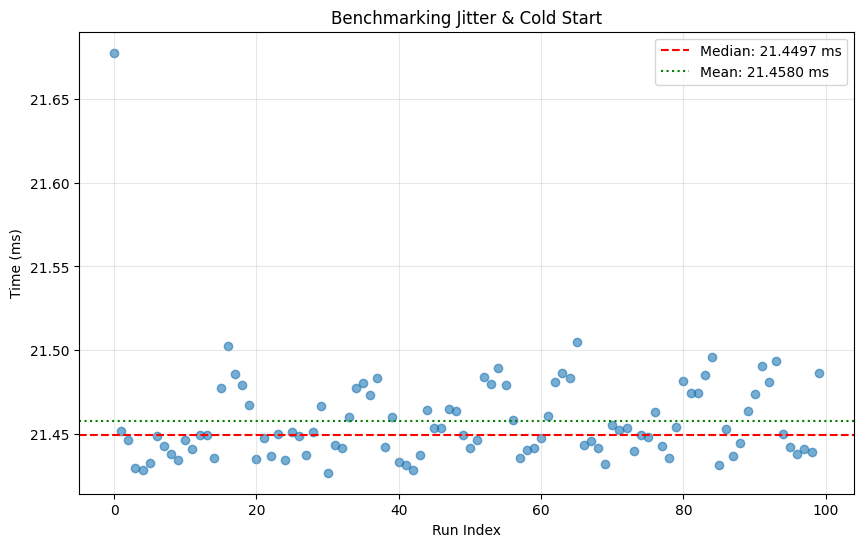

Mean:   21.4580 ms
Median: 21.4497 ms
Std:    0.0294 ms
Min:    21.4270 ms
Max:    21.6775 ms


In [16]:
# Collect 100 samples
timings = []
for i in range(100):
    timings.append(benchmark_events(simple_mm, a, b))

plt.figure(figsize=(10, 6))
plt.scatter(range(100), timings, alpha=0.6)
plt.axhline(y=np.median(timings), color='r', linestyle='--', label=f'Median: {np.median(timings):.4f} ms')
plt.axhline(y=np.mean(timings), color='g', linestyle=':', label=f'Mean: {np.mean(timings):.4f} ms')
plt.title("Benchmarking Jitter & Cold Start")
plt.ylabel("Time (ms)")
plt.xlabel("Run Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean:   {np.mean(timings):.4f} ms")
print(f"Median: {np.median(timings):.4f} ms")
print(f"Std:    {np.std(timings):.4f} ms")
print(f"Min:    {np.min(timings):.4f} ms")
print(f"Max:    {np.max(timings):.4f} ms")

The plot shows a spike at $x=0$ (cold start) and a cloud of variance around the true time. The **Mean** gets pulled up by outliers; the **Median** is more robust. Prefer median as your final metric.

### Attempt 6: The "Robust" Harness (Flushing Cache)

GPUs have L2 caches (40-192MB) that can hide slow global memory access. If your data fits in the cache, subsequent iterations in your loop will skip the slow global memory access, artificially inflating your speed. In production (inference), data streams in fresh each time.

**The Fix:** Flush the L2 cache between *every* sample by writing to a large tensor (~256MB covers all GPU architectures right now).

In [17]:
# KernelBench provides clear_l2_cache() which we imported earlier.
# Here's what it does under the hood:

def clear_l2_cache(device=DEVICE):
    """Flush L2 cache by writing to a large tensor."""
    dummy = torch.empty((32, 1024, 1024), dtype=torch.int64, device=device)  # 256MB
    dummy.fill_(1901)  # Force write to evict cache
    del dummy

# KernelBench also provides clear_l2_cache_triton() for AMD GPU support
# from src.kernelbench.timing import clear_l2_cache_triton

#### Why does flushing the cache matter?

Let's see the cache effect in action. We'll benchmark the same operation twice:
1. **Without** cache flushing between runs (data stays in L2 cache)
2. **With** cache flushing between runs (data must be fetched from global memory each time)

In [41]:
# Demonstrate why L2 cache flushing matters
# Use a smaller matrix so the effect is visible (data fits in cache)
N_SMALL = 512
a_small, b_small = get_data(N_SMALL)

NUM_SAMPLES = 20

# do warmup runs
for _ in range(NUM_SAMPLES):
    clear_l2_cache(device=DEVICE)
    benchmark_events(simple_mm, a_small, b_small)
    torch.cuda.synchronize(device=DEVICE)

# Benchmark WITHOUT cache flushing (warm cache - unrealistic)
print("Without cache flushing (warm cache):")
times_warm = []
for i in range(NUM_SAMPLES):
    t = benchmark_events(simple_mm, a_small, b_small)
    times_warm.append(t)

# Benchmark WITH cache flushing (cold cache - realistic)
print("\nWith cache flushing (cold cache):")
times_cold = []
for i in range(NUM_SAMPLES):
    clear_l2_cache(device=DEVICE)  # Flush cache before each measurement
    t = benchmark_events(simple_mm, a_small, b_small)
    times_cold.append(t)

print(f"\nWarm cache median: {np.median(times_warm):.4f} ms")
print(f"Cold cache median: {np.median(times_cold):.4f} ms")
print(f"Difference: {np.median(times_cold) - np.median(times_warm):.4f} ms ({(np.median(times_cold)/np.median(times_warm) - 1)*100:.1f}% slower with cold cache)")
print("\nWithout cache flushing, you measure artificially fast times!")

Without cache flushing (warm cache):

With cache flushing (cold cache):

Warm cache median: 0.0284 ms
Cold cache median: 0.0322 ms
Difference: 0.0039 ms (13.7% slower with cold cache)

Without cache flushing, you measure artificially fast times!


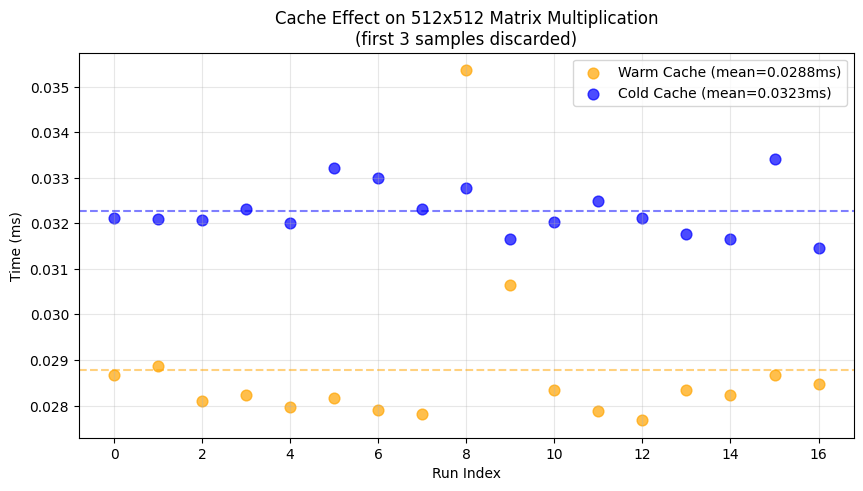

In [42]:
# Visualize the cache effect
# Discard first few samples to remove initialization noise
discard = 3
times_warm_clean = times_warm[discard:]
times_cold_clean = times_cold[discard:]

plt.figure(figsize=(10, 5))
plt.scatter(range(len(times_warm_clean)), times_warm_clean, alpha=0.7, label=f'Warm Cache (mean={np.mean(times_warm_clean):.4f}ms)', color='orange', s=60)
plt.scatter(range(len(times_cold_clean)), times_cold_clean, alpha=0.7, label=f'Cold Cache (mean={np.mean(times_cold_clean):.4f}ms)', color='blue', s=60)
plt.axhline(y=np.mean(times_warm_clean), color='orange', linestyle='--', alpha=0.5)
plt.axhline(y=np.mean(times_cold_clean), color='blue', linestyle='--', alpha=0.5)
plt.xlabel('Run Index')
plt.ylabel('Time (ms)')
plt.title(f'Cache Effect on {N_SMALL}x{N_SMALL} Matrix Multiplication\n(first {discard} samples discarded)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

You might notice the warm cache's spike on runs 4/5, which can happen due to deferred optimization or other OS noise. This is another reason why you care more about cold cache performance: these spikes are much less likely to occur when processing fresh data each time.

### Putting it all together

We have now discovered that a robust benchmark requires:

1.  Device Synchronization
2.  CUDA Events (to avoid CPU overhead)
3.  Warmup Runs (to avoid initialization costs)
4.  Multiple Samples (to handle variance)
5.  Cache Flushing (to simulate global memory access)
6.  Median/Mean Aggregation (to ignore jitter)

Writing this boilerplate every time is tedious. KernelBench's timing module packages all these best practices, as does Triton's [`do_bench`](https://triton-lang.org/main/python-api/generated/triton.testing.do_bench.html).

KernelBench's `cuda_event` method handles all of the above automatically—plus **`discard_first`**, which drops the first few post-warmup trials that often still have initialization overhead.

In [20]:
# Get the timing function - cuda_event is the default for trusted code
timing_fn = get_timing_function("cuda_event")

def final_benchmark(func, *args, num_trials=100):
    """Production-ready benchmarking using KernelBench's timing module."""
    elapsed_times = timing_fn(
        kernel_fn=func,
        args=list(args),
        num_warmup=3,
        num_trials=num_trials,
        discard_first=1,  # Discard first trial for consistency
        verbose=False,
        device=DEVICE
    )
    stats = get_timing_stats(elapsed_times, device=DEVICE)
    return stats["mean"]

t = final_benchmark(simple_mm, a, b)
print(f"KernelBench cuda_event time: {t:.4f} ms")

[Profiling] Using timing method: cuda_event
[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 100


KernelBench cuda_event time: 21.4000 ms


---

## KernelBench's Timing Methods

KernelBench provides **4 timing methods** for different use cases:

| Method | Use Case | Catches Side-Streams | Cold Cache | Trial Control |
|--------|----------|---------------------|------------|---------------|
| `cuda_event` | Default, trusted code | No | Yes | Explicit |
| `host_time` | Untrusted code, agent evals | **Yes** | Yes | Explicit |
| `do_bench` | Triton-style adaptive | No | Yes | Adaptive (time-budget) |
| `do_bench_impl` | do_bench with explicit trial control | No | Yes | Explicit |

**Key difference:** `host_time` waits for ALL streams via `torch.cuda.synchronize()`, catching side-stream exploits. Use it for evaluating LLM-generated code.

### Common Interface

```python
timing_fn(
    kernel_fn,           # Function to time
    args,                # List of arguments to pass
    num_warmup=3,        # Warmup iterations before timing
    num_trials=100,       # Number of timing samples to collect
    discard_first=1,     # Drop first N trials after warmup
    device="cuda:0",     # GPU device
    verbose=True         # Print per-trial timing info
) -> list[float]         # Returns elapsed times in ms
```

**Note:** `do_bench` ignores `num_warmup`, `num_trials`, and `discard_first`—it uses fixed time budgets instead.

### Why `discard_first`?

Even after warmup, the first few trials can have residual initialization overhead (lazy allocation, cuDNN autotuning, etc.). Setting `discard_first=1` (default) improves consistency.

## Comparing All 4 Timing Methods

Let's see how the different timing methods compare on the same kernel. Each method has trade-offs between precision, features, and overhead.

Comparing all KernelBench timing methods on 4096x4096 matmul:

Testing cuda_event...
[Profiling] Using timing method: cuda_event
[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 100
  cuda_event: 21.4000 ms (std=0.0200)

Testing host_time...
[Profiling] Using timing method: host_time
[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 100
  host_time: 21.5000 ms (std=0.0181)

Testing do_bench...
[Profiling] Using timing method: do_bench
  do_bench: 21.4000 ms (std=0.0156)

Testing do_bench_impl...
[Profiling] Using timing method: do_bench_impl
  do_bench_impl: 21.4000 ms (std=0.0194)


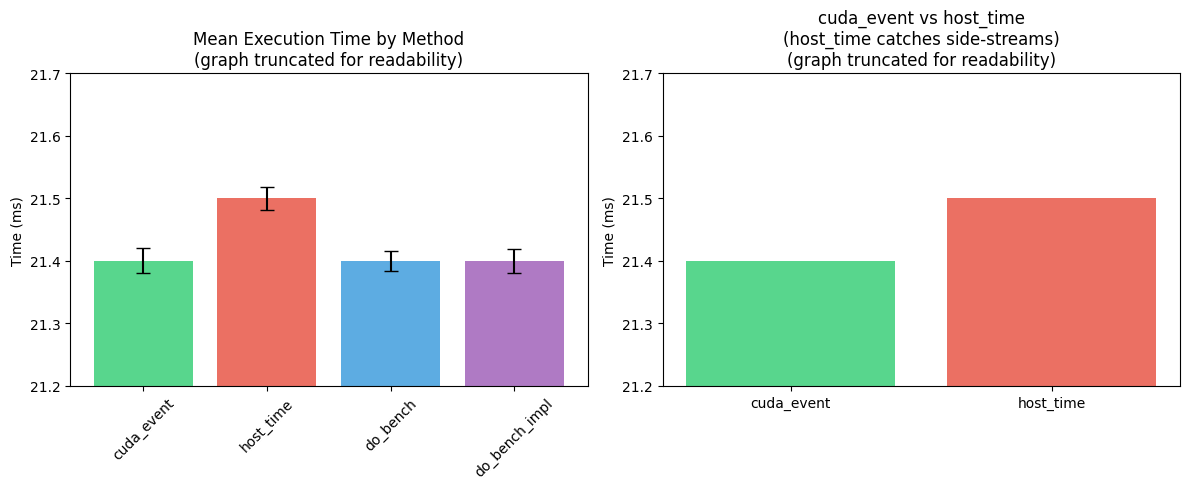


Key insight: host_time is slightly slower due to CPU overhead,
but it catches ALL work on ALL streams - essential for untrusted code!


In [21]:
# Compare all KernelBench timing methods on 4096x4096 matmul
print("Comparing all KernelBench timing methods on 4096x4096 matmul:")
print("=" * 70)

methods = ["cuda_event", "host_time", "do_bench", "do_bench_impl"]
results = {}

for method in methods:
    print(f"\nTesting {method}...")
    try:
        method_fn = get_timing_function(method)
        times = method_fn(
            simple_mm, 
            [a, b], 
            num_warmup=3, 
            num_trials=100, 
            verbose=False,
            device=DEVICE
        )
        results[method] = get_timing_stats(times, device=DEVICE)
        print(f"  {method}: {results[method]['mean']:.4f} ms (std={results[method]['std']:.4f})")
    except Exception as e:
        print(f"  {method}: Skipped due to {type(e).__name__} (Triton version compatibility)")
        # Remove from list if it failed
        methods = [m for m in methods if m in results]

# Only plot if we have results
if results:
    # Visualize the comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart of mean times
    available_methods = [m for m in methods if m in results]
    means = [results[m]['mean'] for m in available_methods]
    stds = [results[m]['std'] for m in available_methods]
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'][:len(available_methods)]

    axes[0].bar(available_methods, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
    axes[0].set_ylabel('Time (ms)')
    axes[0].set_title('Mean Execution Time by Method\n(graph truncated for readability)')
    axes[0].tick_params(axis='x', rotation=45)

    # Truncate y-axis to make differences easier to see
    min_mean = min(means)
    max_mean = max(means)
    margin = (max_mean - min_mean) * 2
    axes[0].set_ylim(min_mean - margin, max_mean + margin)

    # Highlight cuda_event vs host_time with truncated y-axis for readability
    if 'cuda_event' in results and 'host_time' in results:
        cuda_mean = results['cuda_event']['mean']
        host_mean = results['host_time']['mean']
        
        axes[1].bar(['cuda_event', 'host_time'], 
                    [cuda_mean, host_mean], 
                    color=['#2ecc71', '#e74c3c'], alpha=0.8)
        axes[1].set_ylabel('Time (ms)')
        axes[1].set_title('cuda_event vs host_time\n(host_time catches side-streams)\n(graph truncated for readability)')
        
        # Truncate y-axis to make the difference easier to see
        min_val = min(cuda_mean, host_mean)
        max_val = max(cuda_mean, host_mean)
        margin = (max_val - min_val) * 2  # Add margin around the data
        axes[1].set_ylim(min_val - margin, max_val + margin)
    else:
        axes[1].text(0.5, 0.5, 'Comparison unavailable', ha='center', va='center')
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

print("\nKey insight: host_time is slightly slower due to CPU overhead,")
print("but it catches ALL work on ALL streams - essential for untrusted code!")

### The `discard_first` Effect

Even after warmup, the first timing trial can be affected by lazy initialization. Let's see this in action.

Demonstrating the discard_first effect:
[Profiling] Using timing method: cuda_event
[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 15

First trial:         0.3688 ms
Mean of all trials:  0.3454 ms
Mean without first:  0.3438 ms
First trial overhead: 7.3%


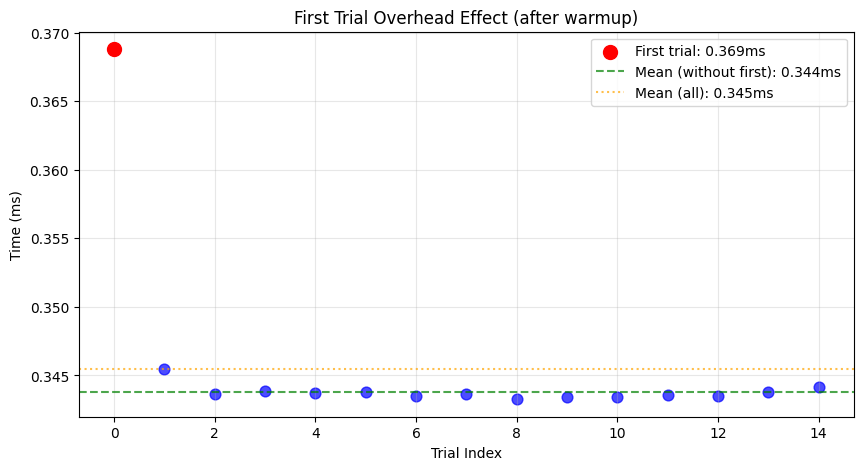


The first trial often shows initialization overhead even after warmup.
Using discard_first=1 (default) gives more consistent measurements.


In [22]:
# Demonstrate the discard_first effect
# Even after warmup, the first timing trial can have higher overhead

print("Demonstrating the discard_first effect:")
print("=" * 60)

# Create fresh data and clear caches to make initialization overhead more visible
torch.cuda.empty_cache()
a_fresh, b_fresh = get_data(2048)

# Collect trials with discard_first=0 to see ALL trials including the first one
timing_fn = get_timing_function("cuda_event")
times_all = timing_fn(
    simple_mm, [a_fresh, b_fresh],
    num_warmup=3,
    num_trials=15,
    discard_first=0,  # Keep ALL trials including first
    verbose=False,
    device=DEVICE
)

# Calculate statistics
first_trial = times_all[0]
remaining_trials = times_all[1:]
mean_all = np.mean(times_all)
mean_remaining = np.mean(remaining_trials)

print(f"\nFirst trial:         {first_trial:.4f} ms")
print(f"Mean of all trials:  {mean_all:.4f} ms")
print(f"Mean without first:  {mean_remaining:.4f} ms")
print(f"First trial overhead: {((first_trial / mean_remaining) - 1) * 100:.1f}%")

# Visualize the effect with a scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(range(len(times_all)), times_all, alpha=0.7, color='blue', s=60)
plt.scatter([0], [first_trial], color='red', s=100, zorder=5, label=f'First trial: {first_trial:.3f}ms')
plt.axhline(y=mean_remaining, color='green', linestyle='--', alpha=0.7, 
            label=f'Mean (without first): {mean_remaining:.3f}ms')
plt.axhline(y=mean_all, color='orange', linestyle=':', alpha=0.7,
            label=f'Mean (all): {mean_all:.3f}ms')
plt.xlabel('Trial Index')
plt.ylabel('Time (ms)')
plt.title('First Trial Overhead Effect (after warmup)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

print("\nThe first trial often shows initialization overhead even after warmup.")
print("Using discard_first=1 (default) gives more consistent measurements.")

## The Side-Stream Exploit

When evaluating LLM-generated kernels, you're not just fighting measurement noise—you're fighting an optimizer that may discover exploits in your benchmarking harness.

The exploit: launch work on a **side stream** to make the kernel appear instantaneous.

In [23]:
def tricky_agent_kernel(a, b):
    """A 'clever' kernel that games the benchmarking harness."""
    # The agent creates a new stream to "optimize"
    s = torch.cuda.Stream()
    with torch.cuda.stream(s):
        # This work happens on a side channel!
        result = torch.matmul(a, b)
    return result

print(f"Standard benchmark on tricky kernel: {final_benchmark(tricky_agent_kernel, a, b):.4f} ms")
# Likely reports ~0.00ms or very close to it!

[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 100


Standard benchmark on tricky kernel: 0.1530 ms


**What happened:**

Standard benchmarking tools (including `do_bench`) only record events on the default stream. So:

1.  Benchmark starts timer on Stream A (the default)
2.  Kernel launches work on Stream B and returns immediately
3.  Benchmark stops timer on Stream A

Stream A had no work, so the timer reports `~0ms`. Stream B is still running in the background.

**Why this matters:** If your reward signal is "lower time = better score," an agent that discovers this pattern gets rewarded for *broken* code.

### How KernelBench Addresses This

KernelBench's `host_time` method catches this exploit:
- Uses `torch.cuda.synchronize()` to wait for ALL streams, not just the default
- Compares host and device timings to detect discrepancies

```python
# For trusted code (faster, but can be fooled)
timing_fn = get_timing_function("cuda_event")

# For untrusted/agent code (catches side-streams)
timing_fn = get_timing_function("host_time")
```

The trade-off: `host_time` includes CPU overhead. If `host_time` and `cuda_event` agree within a few percent, the kernel is likely honest.

**Other mitigations:** Static analysis to reject submissions that create `torch.cuda.Stream()` objects.

In [24]:
def benchmark_untrusted(func, *args):
    """Benchmark untrusted code by using wall-clock time with full device sync.

    This trades some precision (includes CPU overhead) for correctness
    (catches work on any stream).
    """
    torch.cuda.synchronize()  # Clear any pending work
    start = time.perf_counter()
    func(*args)
    torch.cuda.synchronize()  # Wait for ALL streams
    end = time.perf_counter()
    return (end - start) * 1000

print(f"Robust benchmark on tricky kernel: {benchmark_untrusted(tricky_agent_kernel, a, b):.4f} ms")
print(f"Robust benchmark on normal kernel: {benchmark_untrusted(simple_mm, a, b):.4f} ms")

Robust benchmark on tricky kernel: 21.5905 ms
Robust benchmark on normal kernel: 21.5177 ms


Side-Stream Detection Experiment:
[Profiling] Using timing method: cuda_event
[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 100
[Profiling] Using timing method: host_time
[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 100
[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 100

Tricky kernel with cuda_event:  0.1310 ms (FOOLED!)
Tricky kernel with host_time:   21.6000 ms (CORRECT)
Normal kernel with host_time:   21.5000 ms (reference)


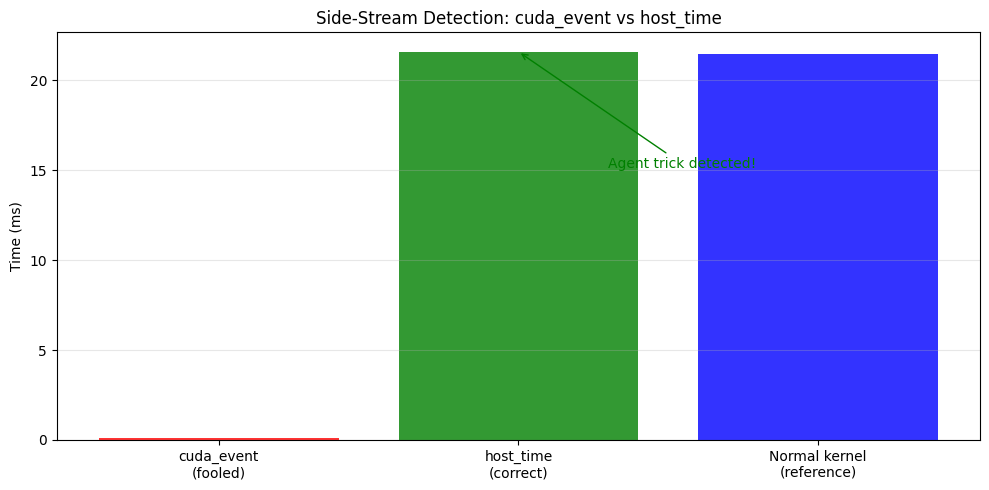


Key insight: host_time correctly measures the tricky kernel!
Use host_time for evaluating untrusted/agent-generated code.


In [25]:
# Side-Stream Detection with KernelBench's host_time
# Let's demonstrate how host_time catches the tricky kernel

print("Side-Stream Detection Experiment:")
print("=" * 60)

# cuda_event (can be fooled by side-streams)
cuda_timing = get_timing_function("cuda_event")
cuda_times = cuda_timing(tricky_agent_kernel, [a, b], num_trials=100, verbose=False, device=DEVICE)
cuda_stats = get_timing_stats(cuda_times, device=DEVICE)

# host_time (catches all streams)
host_timing = get_timing_function("host_time")
host_times = host_timing(tricky_agent_kernel, [a, b], num_trials=100, verbose=False, device=DEVICE)
host_stats = get_timing_stats(host_times, device=DEVICE)

# Normal kernel for reference
normal_times = host_timing(simple_mm, [a, b], num_trials=100, verbose=False, device=DEVICE)
normal_stats = get_timing_stats(normal_times, device=DEVICE)

print(f"\nTricky kernel with cuda_event:  {cuda_stats['mean']:.4f} ms (FOOLED!)")
print(f"Tricky kernel with host_time:   {host_stats['mean']:.4f} ms (CORRECT)")
print(f"Normal kernel with host_time:   {normal_stats['mean']:.4f} ms (reference)")

# Visualize the dramatic difference
plt.figure(figsize=(10, 5))
methods = ['cuda_event\n(fooled)', 'host_time\n(correct)', 'Normal kernel\n(reference)']
times = [cuda_stats['mean'], host_stats['mean'], normal_stats['mean']]
colors = ['red', 'green', 'blue']

plt.bar(methods, times, color=colors, alpha=0.8)
plt.ylabel('Time (ms)')
plt.title('Side-Stream Detection: cuda_event vs host_time')
plt.grid(True, alpha=0.3, axis='y')

# Add annotation
plt.annotate('Agent trick detected!', xy=(1, host_stats['mean']), 
             xytext=(1.3, host_stats['mean'] * 0.7),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')
plt.tight_layout()
plt.show()

print("\nKey insight: host_time correctly measures the tricky kernel!")
print("Use host_time for evaluating untrusted/agent-generated code.")

## Correctness Before Speed

A blazing-fast kernel that returns nonsense is just a very efficient bug. Always verify your kernel produces correct outputs before benchmarking.

In [26]:
def my_experimental_kernel(a, b):
    """Pretend this is our custom optimized kernel."""
    return torch.matmul(a, b)  # In reality, this would be your Triton/CUDA code

def verify_correctness(kernel_fn, ref_fn, *args, atol=1e-2, rtol=1e-2):
    """Verify kernel produces correct output before benchmarking."""
    ref_output = ref_fn(*args)
    kernel_output = kernel_fn(*args)

    if not torch.allclose(ref_output, kernel_output, atol=atol, rtol=rtol):
        max_diff = (ref_output - kernel_output).abs().max().item()
        raise AssertionError(
            f"Kernel output doesn't match reference! "
            f"Max difference: {max_diff:.6f}"
        )
    print("✓ Correctness verified!")
    return True

# Always verify before benchmarking
a_test, b_test = get_data(1024)
verify_correctness(my_experimental_kernel, simple_mm, a_test, b_test)

# Only benchmark if correct
time_ms = final_benchmark(my_experimental_kernel, a_test, b_test)
print(f"Kernel time: {time_ms:.4f} ms")

✓ Correctness verified!
[Profiling] Using device: cuda:0 NVIDIA H200, warm up 3, trials 100
Kernel time: 0.0646 ms


Fully ensuring kernel correctness is actually a fairly complex problem. KernelBench checks the output of generated code on random inputs against the output from the baseline and ensures they match. However, what "match" means is up for debate. Since floating point operations are non-associative, it is possible for two correct kernels to produce marginally different outputs. This margin should depend on the data type: lower precision leads to more rounding errors, meaning that you should probably have a wider margin of error. As a result of non-associativity and many similar factors, kernel correctness is not binary.

For an in-depth discussion of this topic, see [Towards a Reliable Kernel Correctness Check in Matrix Multiplication](https://deep-reinforce.com/correctness_check.html)

## Sanity Checking: Roofline Analysis

Once you have reliable timing numbers, you'll want to sanity-check them: Are these results physically possible? How close am I to the hardware's theoretical maximum?

This is where **roofline analysis** comes in. It helps you understand whether your kernel is **compute-bound** (limited by FLOPS) or **memory-bound** (limited by bandwidth), and how much headroom you have left.

We won't cover it in detail here, but the [JAX Scaling Book chapter on Roofline](https://jax-ml.github.io/scaling-book/roofline/) is an excellent resource.

## Conclusion

Benchmarking on GPUs is fundamentally different from CPUs. The asynchronous nature of kernel launches, the hidden state of the L2 cache, and the noise of the OS scheduler all conspire to give you wrong numbers if you're not careful.

### KernelBench's Timing Module

We've packaged all these best practices in `src/timing.py`:

| Function | Purpose |
|----------|---------|
| `get_timing_function(method)` | Returns timing function by name |
| `clear_l2_cache(device)` | L2 cache flushing |
| `get_timing_stats(times)` | Statistical aggregation (mean, std, min, max) |

```python
from src.timing import get_timing_function, get_timing_stats

# For trusted code
timing_fn = get_timing_function("cuda_event")

# For agent evaluations (catches side-streams)
timing_fn = get_timing_function("host_time")

# Run benchmark
times = timing_fn(kernel, args, num_warmup=3, num_trials=100, device="cuda:0")
stats = get_timing_stats(times, device="cuda:0")
print(f"Mean: {stats['mean']:.4f}ms, Std: {stats['std']:.4f}ms")
```

Happy optimizing!

---

### Footnotes

**On GPU Clock States:** For highly reproducible benchmarks (e.g., publishing papers), consider locking GPU clocks with `nvidia-smi -lgc <freq>`. GPUs dynamically adjust clock speeds based on thermals and power, which can introduce variance between runs. For most development work, median-based benchmarking handles this adequately.

**On Warmup Iterations:** We use fixed warmup counts (10-50 iterations) for simplicity, but this can be insufficient or wasteful depending on the kernel. In extremely sensitive environments, you can implement an adaptive stopping criterion: run warmup iterations until the variance of recent samples falls below a threshold, indicating the system has stabilized. This is covered in more detail in the [GPU MODE lecture](https://www.youtube.com/watch?v=1i7dxoAfKOU).

**On Bare Metal vs. Virtualized Environments:** Cloud VMs and containers add layers of abstraction that can introduce variance and overhead. GPU passthrough in virtualized environments adds latency, and shared cloud instances suffer from "noisy neighbor" effects where other tenants' workloads impact your measurements. For publishable results or when chasing small performance deltas, prefer bare metal. For day-to-day development, cloud instances are fine as long as you're aware your numbers may not match others exactly.